In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss, brier_score_loss
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.calibration import calibration_curve

# Config
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: '%.3f' % x)
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')
sys.path.append(os.getcwd())

try:
    import config as cfg
    FILE_PATH = cfg.FILE_MATCHES_ELO
    print(f"Configuration chargée. Source : {FILE_PATH}")
except ImportError:
    print("'config.py' introuvable")

df_raw = pd.read_csv(FILE_PATH, sep=";", parse_dates=["MatchDate"], dayfirst=True)

# Filtre : Big 5 + Récents (> 2006)
target_divs = ['E0', 'F1', 'D1', 'I1', 'SP1']
df = df_raw[
    (df_raw['Division'].isin(target_divs)) &
    (df_raw['MatchDate'].dt.year >= 2006)
].sort_values("MatchDate").reset_index(drop=True)

# Cible
df["Target"] = df["FTResult"].map({'H': 0, 'D': 1, 'A': 2})

# INTELLIGENCE TEMPORELLE (Rolling Stats)
def add_rolling_stats(df, windows=[5]):
    stats_source = [
        "FTHomeGoals", "FTAwayGoals", 
        "HomeShots", "AwayShots", 
        "HomeCorners", "AwayCorners", 
        "HomeFouls", "AwayFouls",
        "HomeYellow", "AwayYellow",
        "HomeRed", "AwayRed",
        "HomeTarget", "AwayTarget",
        "CardsDiff", "GameDominanceIndex", 
        "ShotsDifference", "CornersDifference" 
    ]
    # On vérifie que les colonnes existent
    stats_source = [c for c in stats_source if c in df.columns]

    new_feats = []
    print(f"Calcul des moyennes glissantes (Last{windows})")
    
    for col in stats_source:
        for w in windows:
            # Stats Domicile (Moyenne des 5 derniers matchs à domicile)
            feat_h = f"H_{col}_Last{w}"
            df[feat_h] = df.groupby("HomeTeam")[col].transform(lambda x: x.shift(1).rolling(window=w).mean())
            new_feats.append(feat_h)
            
            # Stats Extérieur 
            feat_a = f"A_{col}_Last{w}"
            df[feat_a] = df.groupby("AwayTeam")[col].transform(lambda x: x.shift(1).rolling(window=w).mean())
            new_feats.append(feat_a)
            
    return df, new_feats

df, technical_feats = add_rolling_stats(df, windows=[5])

# NETTOYAGE ANTI-LEAKAGE
cols_leak = [
    "FTHome", "FTAway", "FTResult", "HTHome", "HTAway", "HTResult",
    "HomeShots", "AwayShots", "HomeTarget", "AwayTarget",
    "HomeFouls", "AwayFouls", "HomeCorners", "AwayCorners",
    "HomeYellow", "AwayYellow", "HomeRed", "AwayRed",
    "FTHomeGoals", "FTAwayGoals", "CardsDiff", 
    "GameDominanceIndex", "ShotsDifference", "CornersDifference"
]
cols_leak = [c for c in cols_leak if c in df.columns]
df.drop(columns=cols_leak, inplace=True)

# Suppression des lignes incomplètes (Rolling = NaN au début)
cols_mandatory = technical_feats + ["Target", "OddHome", "OddDraw", "OddAway"]
df_model = df.dropna(subset=cols_mandatory).reset_index(drop=True)

print(f"Données prêtes pour RF : {df_model.shape[0]} matchs")
print(f"Variables Techniques : {len(technical_feats)}")

c:\Users\Alban\Documents\IMDS\Projet_5A\Projet_5A_Prediction_matchs\.venv_pred_match\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuration chargée. Source : C:\Users\Alban\Documents\IMDS\Projet_5A\Donnees\Matches_with_Elo.csv
Calcul des moyennes glissantes (Last[5])
Données prêtes pour RF : 32145 matchs
Variables Techniques : 30


Features Sportives identifiées : 36
V0 : PRÉDICTION MARCHÉ (SUIVRE LE FAVORI)
Fold 1 | Fin: 2013-01-26 | Accuracy Marché: 52.44%
Fold 2 | Fin: 2016-02-03 | Accuracy Marché: 53.24%
Fold 3 | Fin: 2019-02-04 | Accuracy Marché: 55.16%
Fold 4 | Fin: 2022-02-13 | Accuracy Marché: 53.16%
Fold 5 | Fin: 2025-02-26 | Accuracy Marché: 54.13%
ACCURACY MOYENNE MARCHÉ : 53.63%
V1 : RANDOM FOREST AVEC COTES (BENCHMARK)
Training sur 39 variables (dont Cotes)
Fold 1 | Modèle: 52.10% vs Marché: 52.44% (Delta: -0.34%)
Fold 2 | Modèle: 53.37% vs Marché: 53.24% (Delta: +0.13%)
Fold 3 | Modèle: 54.96% vs Marché: 55.16% (Delta: -0.21%)
Fold 4 | Modèle: 52.96% vs Marché: 53.16% (Delta: -0.21%)
Fold 5 | Modèle: 53.67% vs Marché: 54.13% (Delta: -0.47%)
Accuracy Globale RF (V1)  : 53.41%
Delta moyen vs Marché     : -0.22%
                   Feature  Importance
                   OddHome       0.105
                   OddAway       0.101
                   EloDiff       0.075
              EloAdvantage       0.06

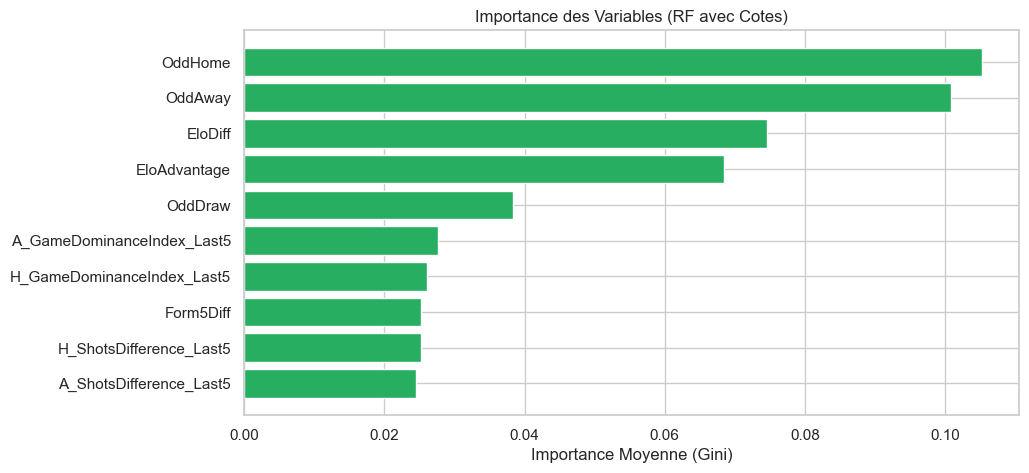

In [2]:
# DÉFINITION DES FEATURES 
# Variables Macro (Elo, Forme)
macro_feats = [
    "EloDiff", "EloAdvantage", 
    "Form3Diff", "Form5Diff", 
    "FormMomentumHome", "FormMomentumAway"
]

# Variables Techniques (Rolling Stats du Bloc 1)
technical_feats = [c for c in df_model.columns if "_Last5" in c]

# Liste Aveugle (Sport uniquement)
features_blind = macro_feats + technical_feats
features_blind = [f for f in features_blind if f in df_model.columns]

print(f"Features Sportives identifiées : {len(features_blind)}")


# V0 : BASELINE MARCHÉ (SANS ML) 
print("V0 : PRÉDICTION MARCHÉ (SUIVRE LE FAVORI)")

# Validation Temporelle
tscv = TimeSeriesSplit(n_splits=5)
market_acc_scores = []

for fold_id, (train_idx, test_idx) in enumerate(tscv.split(df_model)):
    df_test_fold = df_model.iloc[test_idx]
    
    # Stratégie : Cote min = Prédiction
    odds_cols = ["OddHome", "OddDraw", "OddAway"]
    market_preds = df_test_fold[odds_cols].idxmin(axis=1).map({
        "OddHome": 0, 
        "OddDraw": 1, 
        "OddAway": 2
    })
    
    acc = accuracy_score(df_test_fold["Target"], market_preds)
    market_acc_scores.append(acc)
    
    d_date = df_test_fold["MatchDate"].max().date()
    print(f"Fold {fold_id+1} | Fin: {d_date} | Accuracy Marché: {acc:.2%}")

print(f"ACCURACY MOYENNE MARCHÉ : {np.mean(market_acc_scores):.2%}")


# V1 : RANDOM FOREST BENCHMARK (AVEC COTES)
print("V1 : RANDOM FOREST AVEC COTES (BENCHMARK)")

# Création de la liste FULL (Sport + Cotes)
market_feats = ["OddHome", "OddDraw", "OddAway", "ImpProb_Home", "ImpProb_Draw"]
features_full = features_blind + [f for f in market_feats if f in df_model.columns]

print(f"Training sur {len(features_full)} variables (dont Cotes)")

# Modèle
model_full = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    random_state=42, 
    n_jobs=-1
)

# Boucle Comparativa
acc_scores_model = []
feature_importances = np.zeros(len(features_full))
shap_values_full = None

for fold_id, (train_idx, test_idx) in enumerate(tscv.split(df_model)):
    # Data
    X_train = df_model.iloc[train_idx][features_full]
    y_train = df_model.iloc[train_idx]["Target"]
    
    df_test_fold = df_model.iloc[test_idx].copy()
    X_test = df_test_fold[features_full]
    
    # Train
    model_full.fit(X_train, y_train)
    
    # Predict
    preds = model_full.predict(X_test)
    
    # Score
    acc_model = accuracy_score(df_test_fold["Target"], preds)
    acc_scores_model.append(acc_model)
    
    # Comparaison Marché
    acc_market = market_acc_scores[fold_id]
    
    print(f"Fold {fold_id+1} | Modèle: {acc_model:.2%} vs Marché: {acc_market:.2%} (Delta: {acc_model - acc_market:+.2%})")
    
    # Importances
    feature_importances += model_full.feature_importances_
    
    # SHAP (Dernier fold, échantillon)
    if fold_id == 4:
        X_shap_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)
        explainer = shap.TreeExplainer(model_full)
        shap_values_full = explainer.shap_values(X_shap_sample, check_additivity=False)

# Bilan
print(f"Accuracy Globale RF (V1)  : {np.mean(acc_scores_model):.2%}")
print(f"Delta moyen vs Marché     : {np.mean(acc_scores_model) - np.mean(market_acc_scores):+.2%}")

# Preuve Dominance
avg_importance = feature_importances / 5
feat_imp = pd.DataFrame({'Feature': features_full, 'Importance': avg_importance})
top_features = feat_imp.sort_values("Importance", ascending=False).head(10)

print(top_features.to_string(index=False))

# Graphique
plt.figure(figsize=(10, 5))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1], color='#27ae60')
plt.title("Importance des Variables (RF avec Cotes)")
plt.xlabel("Importance Moyenne (Gini)")
plt.show()

In [3]:
# V2 : MODÈLE AVEUGLE VS MARCHÉ
print("V2 : RANDOM FOREST AVEUGLE (SANS COTES)")

# Vérification des Features
print(f"Features utilisées : {len(features_blind)} (Macro + Technique)")

# Définition des poids (Léger boost sur le nul)
weights = df_model["Target"].map({0: 1.0, 1: 1.1, 2: 1.0})

# Configuration du Modèle
model_blind = RandomForestClassifier(
    n_estimators=300, 
    max_depth=10,           # Limite la complexité
    min_samples_leaf=5,     # Lisse les prédictions
    max_features='sqrt',
    random_state=42, 
    n_jobs=-1
)

# Boucle de Validation & Comparaison
tscv = TimeSeriesSplit(n_splits=5)
dfs_results = []
shap_values_blind = None
last_X_test = None # Sera l'échantillon SHAP
acc_scores_blind = []
market_acc_scores = []

for fold_id, (train_idx, test_idx) in enumerate(tscv.split(df_model)):
    # Split X et y
    X_train = df_model.iloc[train_idx][features_blind]
    y_train = df_model.iloc[train_idx]["Target"]
    
    w_train = weights.iloc[train_idx]
    
    df_test_fold = df_model.iloc[test_idx].copy()
    X_test = df_test_fold[features_blind]
    
    # Train et Predict (AVEC sample_weight)
    model_blind.fit(X_train, y_train, sample_weight=w_train)
    
    # Probabilités
    probs = model_blind.predict_proba(X_test)
    preds = np.argmax(probs, axis=1)
    
    acc_model = accuracy_score(df_test_fold["Target"], preds)
    acc_scores_blind.append(acc_model)
    
    # Benchmark Marché (Comparaison immédiate)
    odds_test = df_test_fold[["OddHome", "OddDraw", "OddAway"]]
    preds_market = odds_test.idxmin(axis=1).map({"OddHome": 0, "OddDraw": 1, "OddAway": 2})
    acc_market = accuracy_score(df_test_fold["Target"], preds_market)
    market_acc_scores.append(acc_market)
    
    # Stockage
    df_test_fold["Prob_H"] = probs[:, 0]
    df_test_fold["Prob_D"] = probs[:, 1]
    df_test_fold["Prob_A"] = probs[:, 2]
    df_test_fold["Pred"] = preds
    dfs_results.append(df_test_fold)
    
    # Logs
    d_date = df_test_fold["MatchDate"].max().date()
    print(f"   🔹 Fold {fold_id+1} ({d_date}) | Modèle: {acc_model:.2%} vs Marché: {acc_market:.2%} (Delta: {acc_model - acc_market:+.2%})")
    
    # SHAP (Dernier fold - Optimisé via échantillonnage)
    if fold_id == 4:
        # On prend 500 points au hasard pour éviter que SHAP ne mette 10 minutes
        X_shap_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)
        
        explainer = shap.TreeExplainer(model_blind)
        # check_additivity=False pour éviter les erreurs d'arrondi RF
        shap_values_blind = explainer.shap_values(X_shap_sample, check_additivity=False)
        
        # On sauvegarde l'échantillon, pas tout X_test, pour que les tailles correspondent
        last_X_test = X_shap_sample

# Consolidation
df_results = pd.concat(dfs_results)

# Bilan Global
print(f"Accuracy Globale RF Aveugle : {np.mean(acc_scores_blind):.2%}")
print(f"Accuracy Globale Marché      : {np.mean(market_acc_scores):.2%}")
print(f"Écart de Performance         : {np.mean(acc_scores_blind) - np.mean(market_acc_scores):+.2%}")

V2 : RANDOM FOREST AVEUGLE (SANS COTES)
Features utilisées : 36 (Macro + Technique)
   🔹 Fold 1 (2013-01-26) | Modèle: 51.00% vs Marché: 52.44% (Delta: -1.44%)
   🔹 Fold 2 (2016-02-03) | Modèle: 52.45% vs Marché: 53.24% (Delta: -0.78%)
   🔹 Fold 3 (2019-02-04) | Modèle: 54.28% vs Marché: 55.16% (Delta: -0.88%)
   🔹 Fold 4 (2022-02-13) | Modèle: 51.75% vs Marché: 53.16% (Delta: -1.42%)
   🔹 Fold 5 (2025-02-26) | Modèle: 52.87% vs Marché: 54.13% (Delta: -1.27%)
Accuracy Globale RF Aveugle : 52.47%
Accuracy Globale Marché      : 53.63%
Écart de Performance         : -1.16%


# -> pas de 'balanced' car 3 en poids trop gros

PERFORMANCE GLOBALE (RF AVEUGLE)
Accuracy      : 52.47%
Log Loss      : 0.9871
Brier Score   : 0.2170 (Home Win)
              precision    recall  f1-score   support

        Home       0.53      0.86      0.66     12063
        Draw       0.28      0.01      0.02      6795
        Away       0.52      0.46      0.49      7927

    accuracy                           0.52     26785
   macro avg       0.44      0.44      0.39     26785
weighted avg       0.46      0.52      0.44     26785



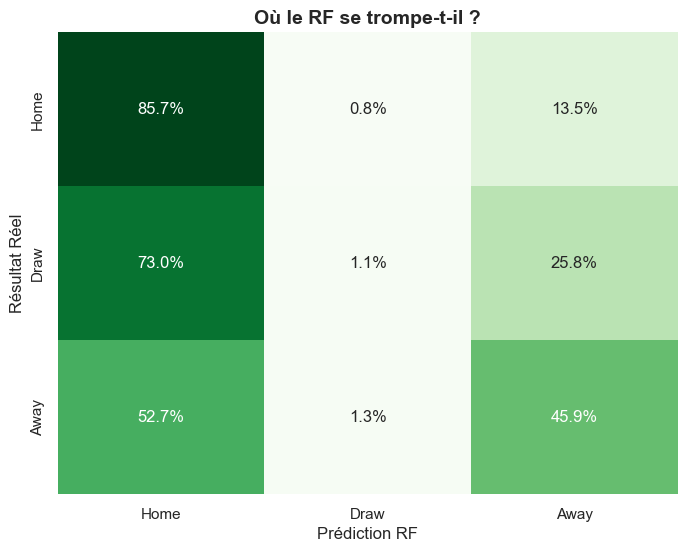

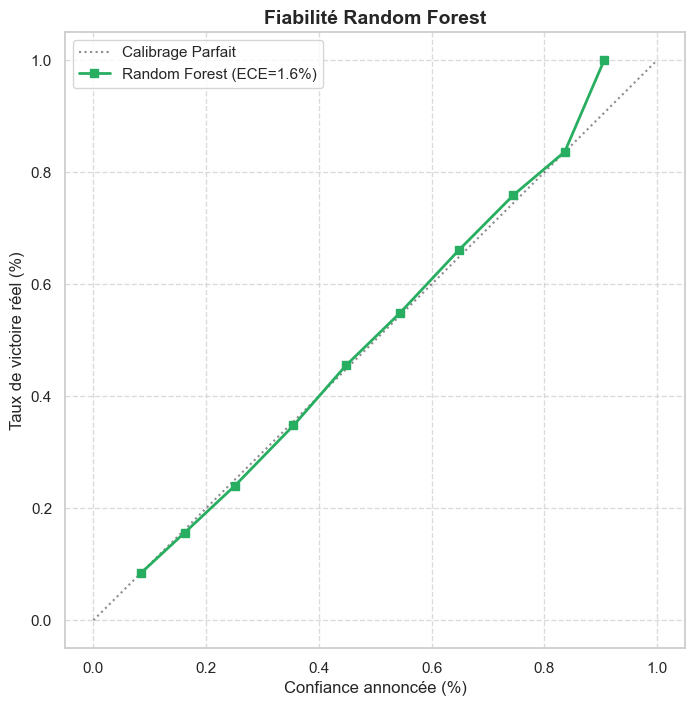

In [4]:
# TABLEAU DE BORD MÉTRIQUES (V2 AVEUGLE)
print("PERFORMANCE GLOBALE (RF AVEUGLE)")

# Calcul des Métriques sur l'ensemble des folds concaténés
acc_global = accuracy_score(df_results["Target"], df_results["Pred"])
ll_global = log_loss(df_results["Target"], df_results[["Prob_H", "Prob_D", "Prob_A"]])
y_true_home = (df_results["Target"] == 0).astype(int)
brier = brier_score_loss(y_true_home, df_results["Prob_H"])

print(f"Accuracy      : {acc_global:.2%}")
print(f"Log Loss      : {ll_global:.4f}")
print(f"Brier Score   : {brier:.4f} (Home Win)")
print(classification_report(df_results["Target"], df_results["Pred"], target_names=["Home", "Draw", "Away"]))

# MATRICE DE CONFUSION 
plt.figure(figsize=(8, 6))
cm_norm = confusion_matrix(df_results["Target"], df_results["Pred"], normalize='true')

sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Greens", cbar=False, 
            xticklabels=["Home", "Draw", "Away"],
            yticklabels=["Home", "Draw", "Away"])

plt.title("Où le RF se trompe-t-il ?", fontsize=14, fontweight='bold')
plt.ylabel("Résultat Réel")
plt.xlabel("Prédiction RF")
plt.show() 

# COURBE DE CALIBRATION
prob_true, prob_pred = calibration_curve(y_true_home, df_results["Prob_H"], n_bins=10, strategy='uniform')
ece = np.mean(np.abs(prob_pred - prob_true))

plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], "k:", label="Calibrage Parfait", alpha=0.5)
plt.plot(prob_pred, prob_true, "s-", color="#27ae60", label=f"Random Forest (ECE={ece:.1%})", linewidth=2)

plt.xlabel("Confiance annoncée (%)")
plt.ylabel("Taux de victoire réel (%)")
plt.title("Fiabilité Random Forest", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

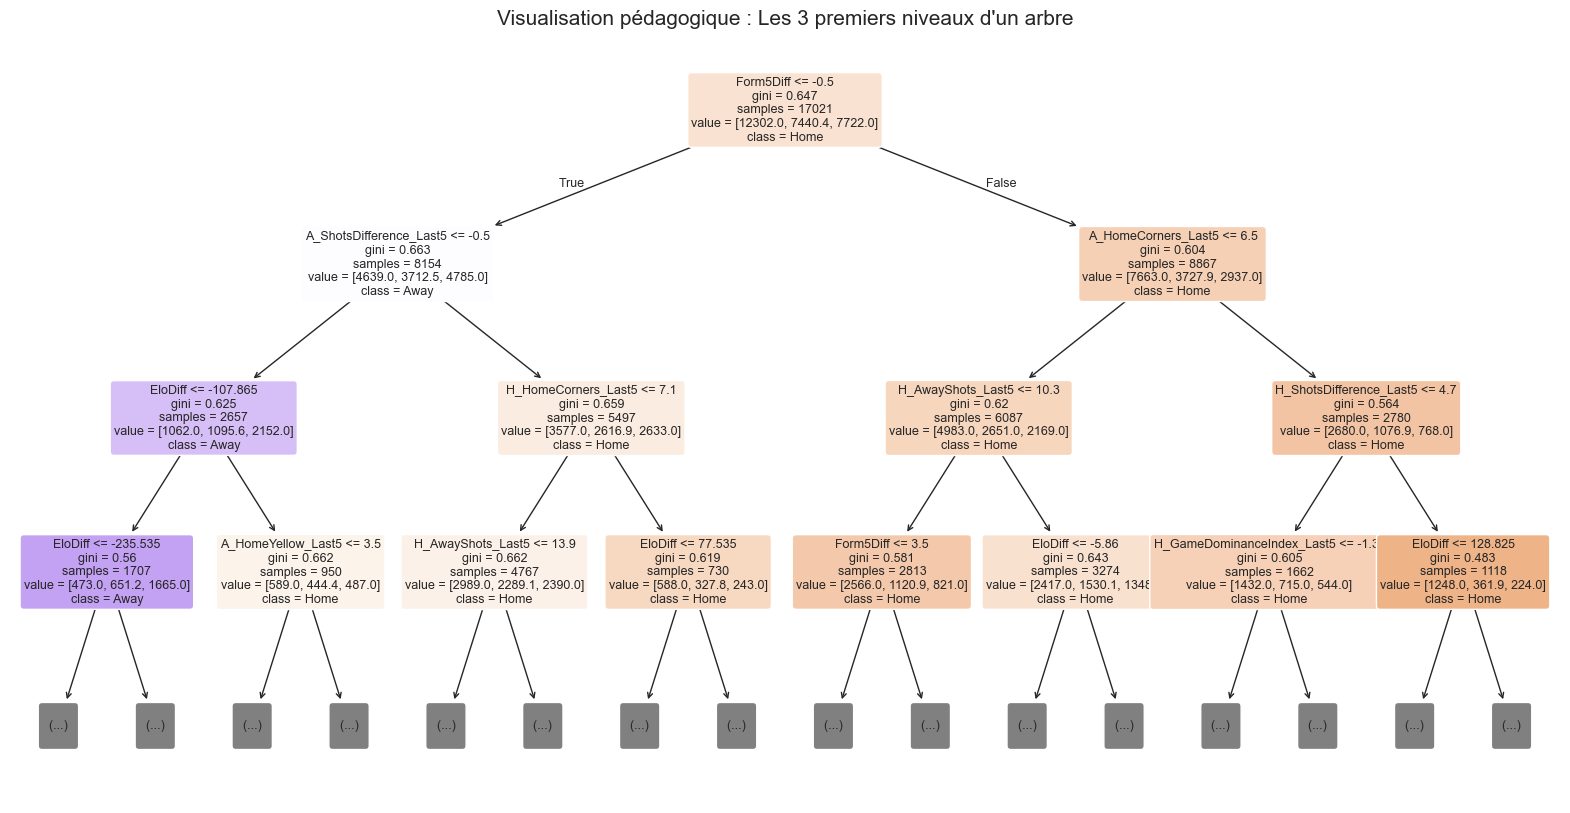

In [5]:
# VISUALISATION : STRUCTURE D'UN ARBRE
from sklearn.tree import plot_tree

# On prend le modèle entraîné 'model_blind' 
if hasattr(model_blind, "estimators_"):
    one_tree = model_blind.estimators_[0] # Le premier arbre

    plt.figure(figsize=(20, 10))
    plot_tree(one_tree, 
              feature_names=features_blind,    # Nos variables
              class_names=["Home", "Draw", "Away"], 
              filled=True, 
              rounded=True, 
              fontsize=9, 
              max_depth=3) # Profondeur limitée pour lisibilité

    plt.title("Visualisation pédagogique : Les 3 premiers niveaux d'un arbre", fontsize=15)
    plt.show()
else:
    print("Le modèle n'est pas une forêt standard scikit-learn")

ANALYSE SHAP (EXPLICABILITÉ)


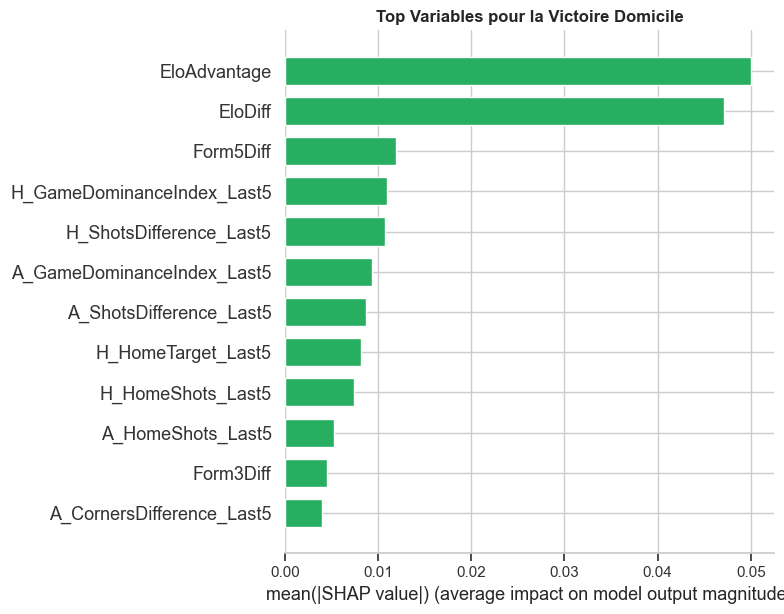

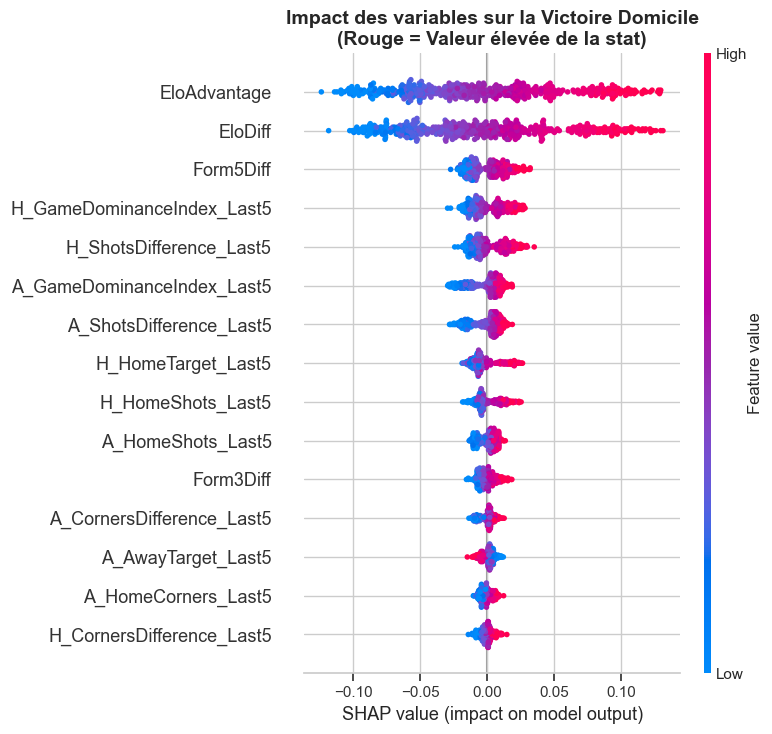

In [6]:
# EXPLICABILITÉ (SHAP)
print("ANALYSE SHAP (EXPLICABILITÉ)")

# Sélection de la cible (Home Win)
if isinstance(shap_values_blind, list):
    # Classe 0 = Home Win
    vals_target = shap_values_blind[0]
    class_label = "Victoire Domicile"
else:
    # Gestion compatibilité array (N_samples, N_features, N_classes)
    if len(shap_values_blind.shape) == 3:
        vals_target = shap_values_blind[:, :, 0]
    else:
        vals_target = shap_values_blind
    class_label = "Victoire Domicile"

# Graphique Importance
plt.figure(figsize=(10, 6))
plt.title("Top Variables pour la Victoire Domicile", fontsize=12, fontweight='bold')
shap.summary_plot(vals_target, last_X_test, plot_type="bar", show=False, max_display=12, color="#27ae60")
plt.show() 

# 3. Graphique Beeswarm (Sens de l'impact)
plt.figure(figsize=(12, 8))
plt.title(f"Impact des variables sur la {class_label}\n(Rouge = Valeur élevée de la stat)", fontsize=14, fontweight='bold')

# Utilisation de last_X_test pour garantir la correspondance des données
shap.summary_plot(vals_target, last_X_test, feature_names=features_blind, show=False, max_display=15)

plt.tight_layout()
plt.show()

In [7]:
# ANALYSE FINANCIÈRE & ROI 
print("ANALYSE DE RENTABILITÉ (MODELE AVEUGLE)")

# Calcul de la "Value" détectée par le modèle
# Value = (Probabilité Modèle * Cote Bookmaker) - 1
df_results["Value_H"] = (df_results["Prob_H"] * df_results["OddHome"]) - 1
df_results["Value_D"] = (df_results["Prob_D"] * df_results["OddDraw"]) - 1
df_results["Value_A"] = (df_results["Prob_A"] * df_results["OddAway"]) - 1

# Simulation de Stratégies (Impact de la sélectivité)
thresholds = [0.00, 0.05, 0.10, 0.15, 0.20]
roi_data = []

print("Simulation des paris (Mise fixe = 1 unité) :")
for th in thresholds:
    # On cherche la meilleure Value du match
    max_vals = df_results[["Value_H", "Value_D", "Value_A"]].max(axis=1)
    best_idxs = df_results[["Value_H", "Value_D", "Value_A"]].idxmax(axis=1)
    
    # On filtre : on ne parie que si la Value > Seuil
    mask_bet = max_vals > th
    bets = df_results[mask_bet].copy()
    
    if len(bets) > 0:
        # Calcul du profit
        rewards = []
        for idx, row in bets.iterrows():
            chosen = best_idxs[idx] # ex: "Value_H"
            
            if chosen == "Value_H":
                profit = (row["OddHome"] - 1) if row["Target"] == 0 else -1
            elif chosen == "Value_D":
                profit = (row["OddDraw"] - 1) if row["Target"] == 1 else -1
            else: # Value_A
                profit = (row["OddAway"] - 1) if row["Target"] == 2 else -1
            rewards.append(profit)
            
        total_profit = sum(rewards)
        roi = (total_profit / len(rewards)) * 100
        
        roi_data.append({
            "Seuil Value >": f"{th:.0%}",
            "Nb Paris": len(rewards),
            "ROI": f"{roi:.2f}%",
            "Profit Total": f"{total_profit:.1f}u"
        })
    else:
        roi_data.append({"Seuil Value >": f"{th:.0%}", "Nb Paris": 0, "ROI": "0.00%", "Profit Total": "0"})

# Affichage propre
res_roi = pd.DataFrame(roi_data)
print(res_roi.to_string(index=False))

ANALYSE DE RENTABILITÉ (MODELE AVEUGLE)
Simulation des paris (Mise fixe = 1 unité) :
Seuil Value >  Nb Paris     ROI Profit Total
           0%     23982  -6.29%     -1507.5u
           5%     18601  -7.23%     -1345.4u
          10%     13138  -9.27%     -1217.6u
          15%      9110 -11.01%     -1003.0u
          20%      6424 -11.63%      -747.0u


In [8]:
# PROFILAGE DES ERREURS (PAR COTE)
print("OÙ GAGNE-T-ON ? (FOCUS VICTOIRE DOMICILE)")

# On découpe les cotes en tranches (Bins)
bins = [1.0, 1.5, 2.0, 3.0, 5.0, 10.0]
labels = ["Ultra Favori (1.0-1.5)", "Favori (1.5-2.0)", "Outsider (2.0-3.0)", "Gros Outsider (3.0-5.0)", "Longshot (5.0+)"]

df_results["Cote_Bin"] = pd.cut(df_results["OddHome"], bins=bins, labels=labels)

# On analyse uniquement les paris "Home Win" pris avec une Value > 5%
mask_home_bet = df_results["Value_H"] > 0.05
df_bets_home = df_results[mask_home_bet].copy()

if len(df_bets_home) > 0:
    # Agrégation par tranche
    profiling = df_bets_home.groupby("Cote_Bin", observed=False).apply(
        lambda x: pd.Series({
            "Nb Paris": len(x),
            "Win Rate Réel": (x["Target"] == 0).mean(),
            "Cote Moyenne": x["OddHome"].mean(),
            "Profit": (x[x["Target"]==0]["OddHome"] - 1).sum() - len(x[x["Target"]!=0])
        })
    )
    
    profiling["ROI"] = (profiling["Profit"] / profiling["Nb Paris"]) * 100
    
    print(profiling[["Nb Paris", "Win Rate Réel", "Cote Moyenne", "Profit", "ROI"]])
else:
    print("Pas assez de paris Home pour profiler")

OÙ GAGNE-T-ON ? (FOCUS VICTOIRE DOMICILE)
                         Nb Paris  Win Rate Réel  Cote Moyenne   Profit    ROI
Cote_Bin                                                                      
Ultra Favori (1.0-1.5)    267.000          0.663         1.414  -17.440 -6.532
Favori (1.5-2.0)          848.000          0.557         1.772  -18.730 -2.209
Outsider (2.0-3.0)       2691.000          0.387         2.509 -115.600 -4.296
Gros Outsider (3.0-5.0)  2035.000          0.241         3.823 -199.170 -9.787
Longshot (5.0+)          1371.000          0.144         7.002  -21.320 -1.555
